<a href="https://colab.research.google.com/github/Ritapaz/introduction-to-github/blob/main/Simula%C3%A7%C3%A3o%2Bde%2BAtendimento%2Bao%2BCliente%2B%2BMelhorando%2Ba%2BEfici%C3%AAncia%2Bem%2BFilas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulação de atendimento ao Cliente

## Contexto

O atendimento ao cliente é fundamental em qualquer empresa e, especialmente em setores como bancos, farmácias e lojas, onde a espera em filas pode ser frustrante para os clientes. Com o objetivo de melhorar a experiência do cliente e a eficiência do atendimento, esse projeto de simulação de atendimento ao cliente visa avaliar o tempo de espera e a eficiência da fila em uma instituição financeira, farmácia ou loja. Utilizando ferramentas de simulação, será possível criar modelos para simular diferentes cenários e avaliar o impacto das mudanças nas filas e no atendimento ao cliente. Ao final do projeto, serão apresentadas soluções para melhorar a eficiência do atendimento e a satisfação do cliente.

## Conceitos

1. Yield é uma palavra-chave em Python que é usada em funções geradoras para indicar o retorno de um valor. Ao contrário das funções normais que retornam um valor usando a palavra-chave "return", as funções geradoras usam "yield" para produzir valores em uma seqüência.

2. Env é uma classe em simpy que é usada para representar o ambiente de simulação. É o objeto principal que controla a simulação, incluindo a data e hora atual, a lista de processos a serem executados e a capacidade de agendar eventos futuros.

3. Resource é uma classe em simpy que é usada para representar recursos compartilhados, como uma fila de atendimento. Ela controla a disponibilidade de recursos, alocando-os a processos e gerenciando a fila de espera.

4. Seed é uma semente usada para inicializar o gerador de números aleatórios. É importante usar a mesma semente em simulações para garantir que os resultados sejam consistentes e possam ser reproduzidos.

Em resumo, yield, env, resource e seed são elementos-chave em simulações utilizando simpy, onde "yield" é usado para produzir resultados, "env" é o ambiente de simulação, "resource" representa recursos compartilhados e "seed" é usada para garantir a consistência dos resultados. Eles trabalham juntos para permitir a simulação de processos e a análise de seus resultados.

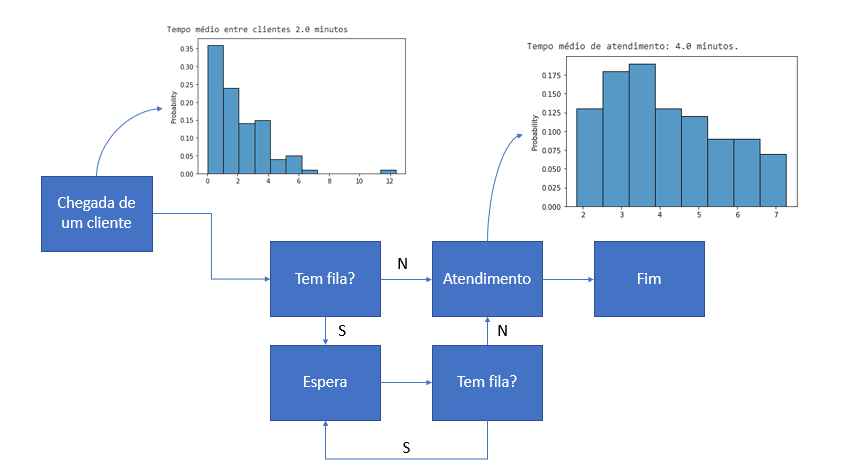

In [1]:
!pip install simpy

In [2]:
import numpy as np
import random
import simpy
import seaborn as sns

In [6]:
class Bank(object):
    """Um banco com uma quantidade de guiches e de tempos de atendimento"""
    def __init__(self, env, num_tellers, service_time):
        self.env = env
        self.caixa = simpy.Resource(env, num_tellers)
        self.service_time = service_time


    # Definindo Atendimento ao cliente
    def atendimento(self):
      "Retorna o tempo de atendimento ao cliente"
      #distribuição triangular
      yield self.env.timeout(np.random.triangular(self.service_time[0], self.service_time[1], self.service_time[2]))



def processo_cliente(env, cliente, banco):
  """Um cliente chega ao banco e espera na fila para ser atendido"""
  arrive = env.now
  #Solicita atendimento
  with banco.caixa.request() as request:
    yield request
    #Tempo de espera
    espera = round(env.now - arrive, 1)
    print(f"{cliente} esperou {espera} minutos.")
    yield env.process(banco.atendimento())
    print("{} terminou o atendimento em {} minutos.".format(cliente, round(env.now,1)))

# Definindo função para simular
def rodar_simulacao(env, n_caixas, tempo_atendimento, taxa_chegada_clientes):
  id = 1

  #Cria o ambiente Banco
  BANCO = Bank(env, n_caixas, tempo_atendimento)

  while True:

    print('Cliente {} chegou em {} minutos.'.format(id, round(env.now,1)))
    print('A fila é de {} clientes.'.format(len(BANCO.caixa.queue)+1))

    #Processo de atendimento
    env.process(processo_cliente(env, f"Cliente {id}", BANCO))

    #Tempo para chegada do próximo cliente (taxa de chegada)
    #Tempo de chegada: distribuição exponencial
    yield env.timeout(random.expovariate(1/taxa_chegada_clientes))

    id += 1 #Id do próximo cliente


RANDOM_SEED = 42 # Semente de geração de números aleatórios
NUM_TELLERS = 1  # Número de guichês no banco
SIM_TIME = 100  # Tempo de simulação (em minutos)
TAXA_CHEGADA = 2 # 1 cliente a cada 2 minutos
TEMPO_ATENDIMENTO = [1, 5, 8] #Mín, Moda e Máx (min)

# Configuração da simulação
random.seed(RANDOM_SEED)
#Cria ambiente do Simpy
env = simpy.Environment()
env.process(rodar_simulacao(env, NUM_TELLERS, TEMPO_ATENDIMENTO, TAXA_CHEGADA))
env.run(until=SIM_TIME)


Cliente 1 chegou em 0 minutos.
A fila é de 1 clientes.
Cliente 1 esperou 0 minutos.
Cliente 2 chegou em 2.0 minutos.
A fila é de 1 clientes.
Cliente 3 chegou em 2.1 minutos.
A fila é de 2 clientes.
Cliente 4 chegou em 2.7 minutos.
A fila é de 3 clientes.
Cliente 5 chegou em 3.2 minutos.
A fila é de 4 clientes.
Cliente 6 chegou em 5.9 minutos.
A fila é de 5 clientes.
Cliente 1 terminou o atendimento em 6.3 minutos.
Cliente 2 esperou 4.3 minutos.
Cliente 7 chegou em 8.2 minutos.
A fila é de 5 clientes.
Cliente 2 terminou o atendimento em 8.2 minutos.
Cliente 3 esperou 6.1 minutos.
Cliente 3 terminou o atendimento em 10.9 minutos.
Cliente 4 esperou 8.1 minutos.
Cliente 8 chegou em 12.6 minutos.
A fila é de 4 clientes.
Cliente 9 chegou em 12.8 minutos.
A fila é de 5 clientes.
Cliente 10 chegou em 13.9 minutos.
A fila é de 6 clientes.
Cliente 11 chegou em 14.0 minutos.
A fila é de 7 clientes.
Cliente 12 chegou em 14.5 minutos.
A fila é de 8 clientes.
Cliente 4 terminou o atendimento em 14.8

Tempo médio de atendimento: 4.7 minutos.


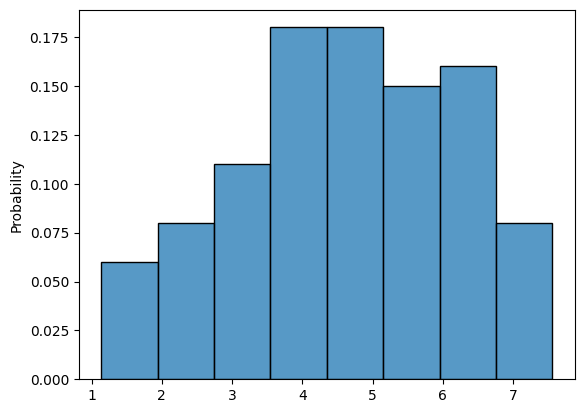

In [7]:
print('Tempo médio de atendimento: {} minutos.'.format(round(np.random.triangular(TEMPO_ATENDIMENTO[0],TEMPO_ATENDIMENTO[1], TEMPO_ATENDIMENTO[2], size=100).mean(),1)))
sns.histplot(np.random.triangular(TEMPO_ATENDIMENTO[0],TEMPO_ATENDIMENTO[1], TEMPO_ATENDIMENTO[2], size=100), stat='probability');

Tempo médio entre clientes 2.0 minutos


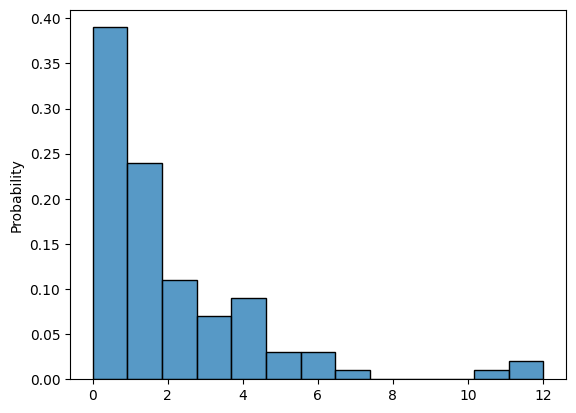

In [8]:
taxa_chegada_media = 2
tempos_chegada = np.array([random.expovariate(1/taxa_chegada_media) for i in range(100)])
print('Tempo médio entre clientes {} minutos'.format(tempos_chegada.mean().round()))
sns.histplot(tempos_chegada, stat='probability');